# Recreation Testing

## Overview
A reviewer might flag our current method of recreating red spots around the border to be too different from an actual case that occurs in real tumors. The goal of this notebook is to discover methods on creating these cases more acurately

## Different Possibilities 

Using these images below We will see how exactly we can format these images.

In [ ]:
# imports 
import cv2, torch, yaml
import matplotlib.pyplot as plt
from detectron2.config import get_cfg
from detectron2 import model_zoo
from failure_recreation import FailureRecreation

## Reference Images 

First we will look at some images that do have this discoloration, and as we previously saw, these images were found through examining "failed" cases for RGB. This is how we originally came up with the idea for this simulation. Below are some images where this comes about

## Recreation Brainstorm 

Some ideas of how to create scenrios that may be more accruate on some real life failure conditions of the scanner or the tumor itself.

This image will be the one used to make comparisons between different methods, here is the name: 

"013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr"

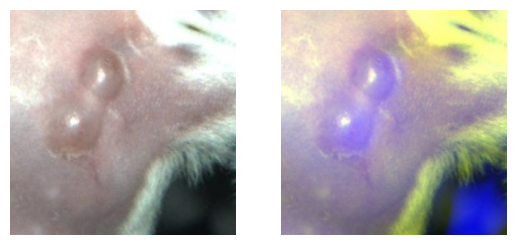

In [4]:
# load the image and its RGD equivlant
rgb_path = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
rgd_path = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"

rgb = cv2.imread(rgb_path)
rgd = cv2.imread(rgd_path)
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
rgd = cv2.cvtColor(rgd, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(rgb)
ax[1].imshow(rgd)

ax[0].axis(False)
ax[1].axis(False)

plt.show()

### Specular Highlights 

These are highlights/changes in lighting that can take place on a smooth part of the mice skin, which could obseure the boundry. While there are many examples of this, we can see this happening in our example tumor within the tumor region itself. The main issue is that this type of texture is unpredictable, some of the mice used aren't shaved as much, leading to less highlighting, while some are shaved more. 

Regardless, we can simulate this using the same code as the previous red patch method. While the reflectivness of the skin can happen anywhere, I've decided to just focus on the edge case where the reflectiveness can happen on/near the tumor boundry.

- RGB: Add highlights in the RGB channels, using a similar random area generator to the red region 
- RGD: Only affect the green and blue channels but have the same effect

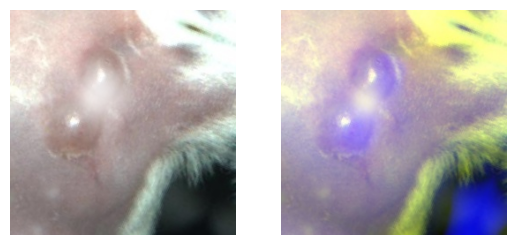

In [6]:
# code for generating specular highlights 
with open("config.yaml") as f:
    yaml_config = yaml.safe_load(f)

# enable correct augmentation 
yaml_config['options']['shadows'] = False 
yaml_config['options']['specular'] = True

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

IMAGE_RGB = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGB  = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

IMAGE_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

fr = FailureRecreation(cfg, output_path="/tmp/fr_out", yaml_config=yaml_config)

aug_rgb = fr.augment_image(IMAGE_RGB, MASK_RGB)
aug_rgd = fr.augment_image(IMAGE_RGD, MASK_RGD)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(cv2.cvtColor(aug_rgb, cv2.COLOR_BGR2RGB))
ax[0].axis(False)
ax[1].imshow(cv2.cvtColor(aug_rgd, cv2.COLOR_BGR2RGB))
ax[1].axis(False)

plt.show()

### Brightness Variation 

Some images are more well lit than others, so increasing/decreasing the brightness image wide could also simulate an effect that depth information would solve. The cavat to this is that the RGD model would only have a reduced/increased red and green channel, and since blue is correleted with a tumor region, this might have the adverse effect of increasing/decreasing the tumor boundry. 

However since this a valid concern that can happen with the scanner, I think its a good test to have.


- RGB: Reduce brightness image-wide for all 3 channels 
- RGD: Reduce brightness image-wide for RG channels

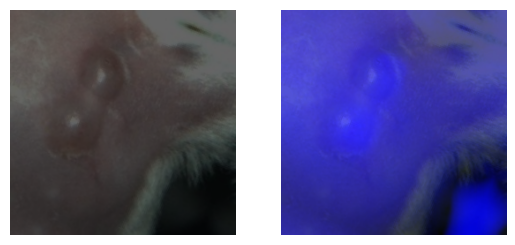

In [4]:
# code for generating brightness vairation
with open("config.yaml") as f:
    yaml_config = yaml.safe_load(f)

# enable correct augmentation 
yaml_config['options']['shadows'] = False 
yaml_config['options']['brightness'] = True

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

IMAGE_RGB = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGB  = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

IMAGE_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

fr = FailureRecreation(cfg, output_path="/tmp/fr_out", yaml_config=yaml_config)

aug_rgb = fr.augment_image(IMAGE_RGB, MASK_RGB)
aug_rgd = fr.augment_image(IMAGE_RGD, MASK_RGD)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(cv2.cvtColor(aug_rgb, cv2.COLOR_BGR2RGB))
ax[0].axis(False)
ax[1].imshow(cv2.cvtColor(aug_rgd, cv2.COLOR_BGR2RGB))
ax[1].axis(False)

plt.show()

### Necrotic Regions

This idea was something we discussed before. This method generates a patch near the central region of the tumor and significantly darks it. Both models seem to preform well on necrotic regions but I have included it here anyway. 

This comparison might not make sense since a necrotic region might be lower in height comapared to another tumor, but this is a bit complex to simulate and I'm not sure how to approach this if I wanted to take account for it.

- RGB: finds a central region of interest with the random blob format used in the red region code, and then darken that region of interest 
- RGD: Same steps, but only modify the red and green channel



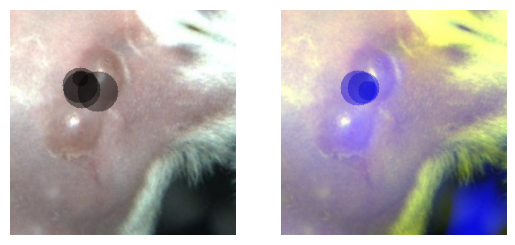

In [3]:
# code for generating necrotic regions
with open("config.yaml") as f:
    yaml_config = yaml.safe_load(f)

# enable correct augmentation
yaml_config['options']['shadows'] = False
yaml_config['options']['necrotic'] = True

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

IMAGE_RGB = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGB  = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

IMAGE_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/images/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.jpg"
MASK_RGD = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/test/masks/Tumor/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_aug_hvr.png"

fr = FailureRecreation(cfg, output_path="/tmp/fr_out", yaml_config=yaml_config)

aug_rgb = fr.augment_image(IMAGE_RGB, MASK_RGB)
aug_rgd = fr.augment_image(IMAGE_RGD, MASK_RGD)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(cv2.cvtColor(aug_rgb, cv2.COLOR_BGR2RGB))
ax[0].axis(False)
ax[1].imshow(cv2.cvtColor(aug_rgd, cv2.COLOR_BGR2RGB))
ax[1].axis(False)

plt.show()